# Week 3 Assignment


### **Project Workflow** : Data Collection & Understanding  •  Data Cleaning & Preprocessing  •  Exploratory Data Analysis (EDA)  •  Feature Selection • Feature Scaling • K-Means Clustering • DBSCAN Clustering • Hierarchical Clustering • PCA Scatter plot • Cluster Analysis & Interpretation • NGO Recommendation Analysis • Train-Test Split • Classification using Random Forest, Decision Tree, KNN, SVM, and XGBoost • Model Comparison & Evaluation



# Section 1: Import Libraries
We load the core libraries needed for data manipulation, mathematical operations, and machine learning models. We also turn off unnecessary warnings to keep our outputs clean

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN,  AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Section 2: Load Dataset
We load the `Country-data.csv` file into our environment.The dataset contains socio-economic and health indicators of different countries. These features will be used to group countries based on their level of development and identify nations that require the most humanitarian aid.

We print the shape and column types to understand the structure of our raw data.

In [ ]:
df=pd.read_csv("/content/Country-data.csv")
df.head()
print("Shape:", df.shape)
df.info()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# Section 3: Data Cleaning
->Remove extra spaces

->Remove duplicates

->Check missing values and fill them

->Convert numeric columns

In [ ]:
#Remove extra spaces
df.columns = df.columns.str.strip()

#Remove duplicates
df.drop_duplicates(inplace=True)

#Check missing values
print(df.isnull().sum())

#Convert numerical columns
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

#Fill missing values
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)



country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [ ]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# Section 4: Exploratory Data Analysis

In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


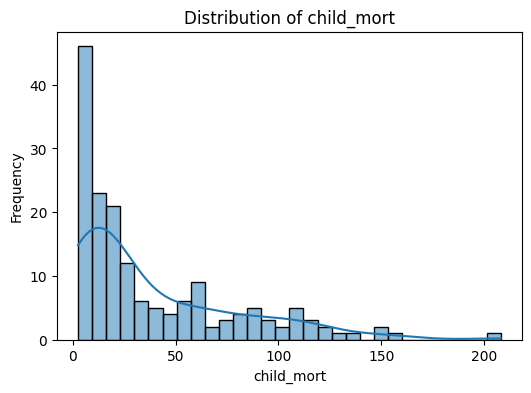

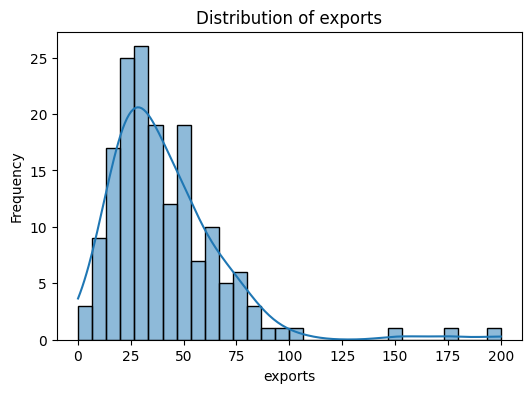

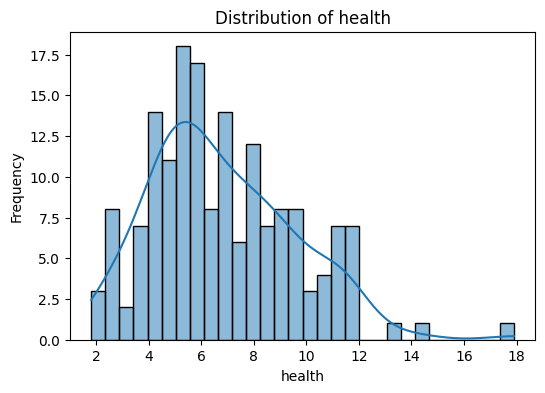

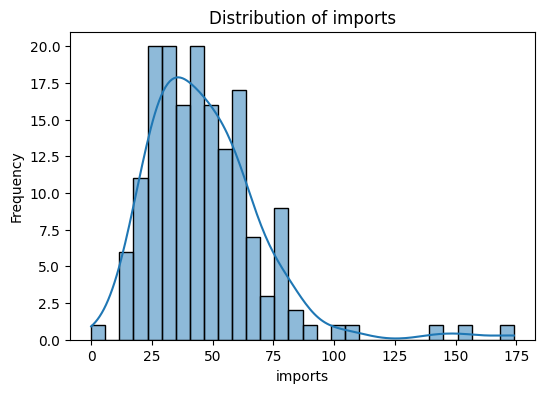

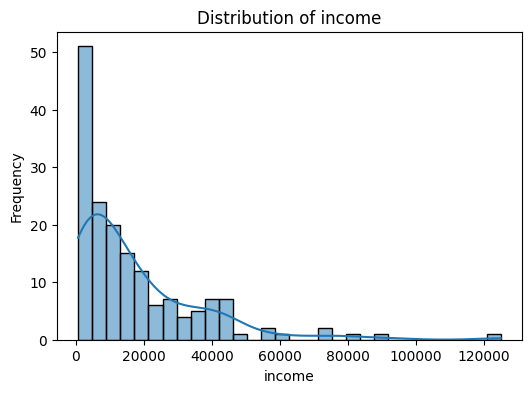

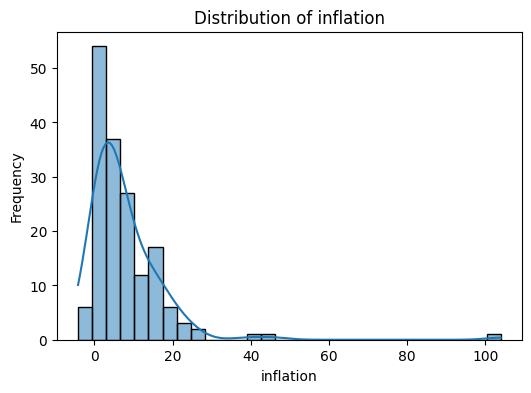

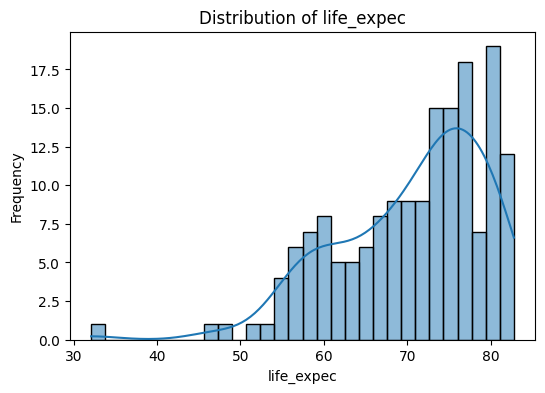

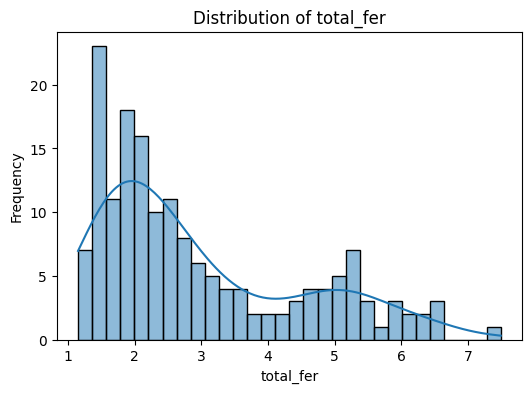

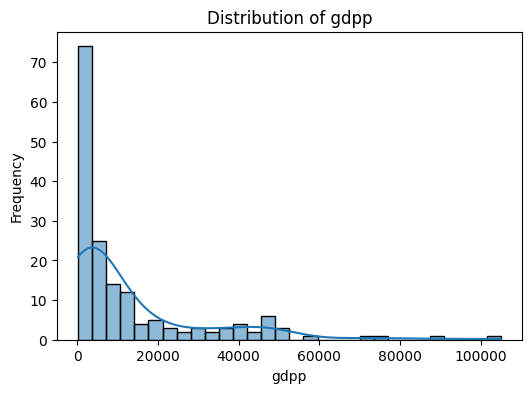

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Correlation Heatmap**

We generate a correlation heatmap. This helps us see how different socio-economic factors like wealth, inflation, and health spending relate to each other.

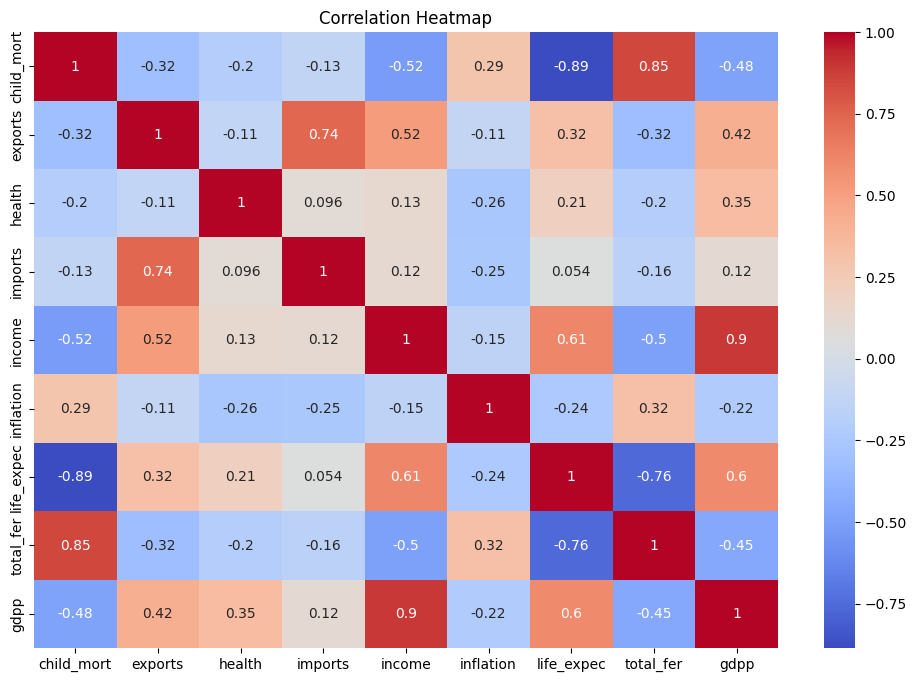

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Insights from Correlation Heatmap

1) Income and GDP per Capita show a strong positive correlation.

2) Life Expectancy is positively correlated with Income and GDP.

3) Child Mortality is negatively correlated with Income and Life Expectancy.

4) Total Fertility Rate is positively correlated with Child Mortality.

5) Child Mortality is negatively correlated with GDP per Capita.

6) Income, GDP per Capita, and Life Expectancy form a strong positive relationship group.

7) Inflation shows relatively weak correlations with most variables.


# Section 5: Feature Selection
We drop the country text labels to focus purely on numeric values.

In [ ]:
# Store country names separately
countries = df['country']
#Remove country column
X = df.drop('country', axis=1)

# Section 6: Feature Scaling
we use `StandardScaler` to bring all metrics onto the same mathematical scale.

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# Section 7: Elbow Method
We run an optimization loop testing clusters from $k=2$ to $k=10$. We map the inertia values to find the "elbow" point where adding more clusters no longer helps.

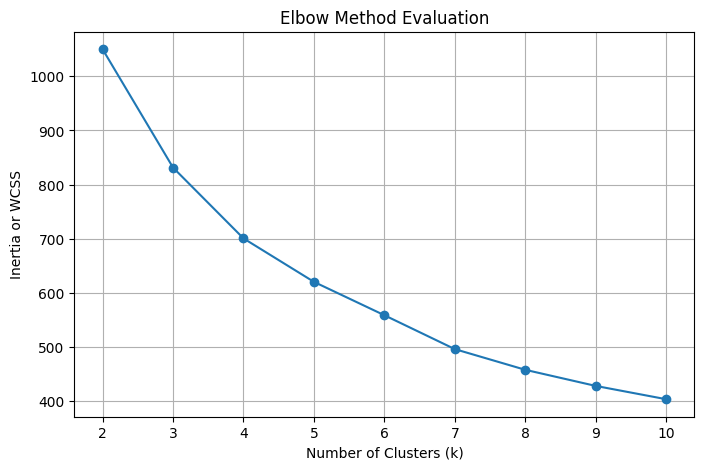

In [ ]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia or WCSS")
plt.title("Elbow Method Evaluation")
plt.grid(True)
plt.show()


**Observation**

WCSS decreases as K increases.

After a certain point, the decrease becomes slow.

The "elbow point" is the optimal number of clusters.
Based on the graph, we select K = 3 (usually for this dataset).

# Section 8: K-Means model
Based on the Elbow Method, we choose K = 3 to segment countries into 3 groups:

Developed

Developing

Underdeveloped

We evaluate its performance by logging the Silhouette Score



In [ ]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, kmeans_labels)
df['KMeans_cluster'] = kmeans_labels
print(f"Silhouette Score for k=3 is {score:.4f}")
df.head()

Silhouette Score for k=3 is 0.2833


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


# Section 9: DBSCAN
We build a secondary model using DBSCAN to look for high-density country groups. This helps us identify outliers or noise points in our country records.

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())

print(f"\nNoise points: {(df['DBSCAN_Cluster'] == -1).sum()}")

# Calculate silhouette score only if there are at least 2 clusters
labels = df['DBSCAN_Cluster']

if len(np.unique(labels)) > 1:
    print(f"DBSCAN Silhouette Score: {silhouette_score(X_scaled, labels):.4f}")
else:
    print("Silhouette Score cannot be calculated (only one cluster found).")

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

Noise points: 30
DBSCAN Silhouette Score: 0.2883


# Section 10: Heirarchical clustering
To double-check our results, we train an Agglomerative Hierarchical Clustering model. We evaluate its silhouette score to compare its stability against K-Means.

In [ ]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hc_labels
print(f"Hierarchical Silhouette Score: {silhouette_score(X_scaled, hc_labels):.4f}\n")

Hierarchical Silhouette Score: 0.2456



# Section 11: PCA
We compress our high-dimensional country data into 2D space using Principal Component Analysis (PCA).

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions to 2 principal components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(data=pca_data,columns=['PC1', 'PC2'])

# Add K-Means cluster labels
pca_df['Cluster'] = kmeans_labels

# Section 12: PCA Scatter Plot
We map our K-Means groups onto a high-contrast scatterplot.




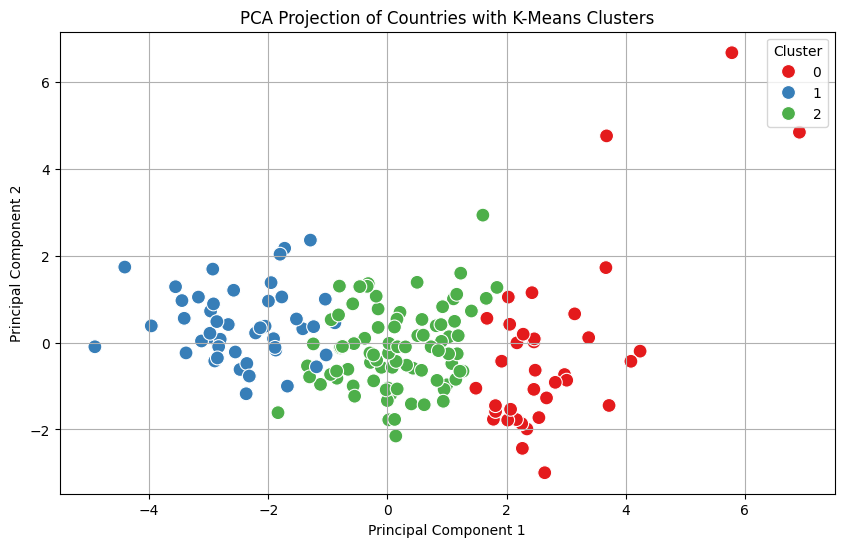

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='PC1',y='PC2',hue='Cluster',palette='Set1',data=pca_df,s=100)

plt.title('PCA Projection of Countries with K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Section 13: Cluster Analysis and Interpretation

### **Cluster Profiling**

We calculate the mean values for every feature across our three K-Means clusters. This gives us the exact economic and health numbers needed for our final analysis.

In [ ]:
# Cluster Profiling
cluster_profile = df.groupby('KMeans_cluster').mean(numeric_only=True)
print(cluster_profile)

                child_mort    exports    health    imports        income  \
KMeans_cluster                                                             
0                 5.000000  58.738889  8.807778  51.491667  45672.222222   
1                92.961702  29.151277  6.388511  42.323404   3942.404255   
2                21.927381  40.243917  6.200952  47.473404  12305.595238   

                inflation  life_expec  total_fer          gdpp  \
KMeans_cluster                                                   
0                2.671250   80.127778   1.752778  42494.444444   
1               12.019681   59.187234   5.008085   1922.382979   
2                7.600905   72.814286   2.307500   6486.452381   

                DBSCAN_Cluster  Hierarchical_Cluster  
KMeans_cluster                                        
0                    -0.250000              0.138889  
1                    -0.340426              1.574468  
2                    -0.059524              0.964286  


### **Cluster Label Assignment**

Based on the cluster profiling results, meaningful labels were assigned to each cluster.These labels improve interpretability and help in understanding the socio-economic status of countries within each cluster.

**0 - Developed Countries**

(highest average income, highest GDP per capita, highest life expectancy, lowest child mortality rate, lowest inflation rate)


**1 - Underdeveloped Countries**

(lowest average income, lowest GDP per capita, lowest life expectancy, highest child mortality rate, highest fertility rate)

**2 - Developing Countries**

(Moderate income levels, Moderate GDP per capita, Moderate life expectancy, Medium child mortality, Medium inflation and fertility rates)




In [ ]:
# Assign meaningful labels to clusters
cluster_labels = {
    0: 'Developed',
    1: 'Underdeveloped',
    2: 'Developing'
}
df['Cluster_Label'] = df['KMeans_cluster'].map(cluster_labels)

df[['country', 'KMeans_cluster', 'Cluster_Label']].head()

,country,KMeans_cluster,Cluster_Label
0,Afghanistan,1,Underdeveloped
1,Albania,2,Developing
2,Algeria,2,Developing
3,Angola,1,Underdeveloped
4,Antigua and Barbuda,2,Developing


### **Cluster Size Analysis**
The number of countries present in each cluster was calculated to understand the distribution of countries across different segments.

In [ ]:
df['Cluster_Label'].value_counts()

,count
Cluster_Label,
Developing,84
Underdeveloped,47
Developed,36


# Section 14: High impact analysis

### **Observation 1:** High-Mortality Clusters (The Dire Need Zone)

**The Data**: Cluster 1 shows the highest child mortality. It averages nearly 93 deaths per 1,000 births. People here earn the lowest income. They make only about $3,942 a year. Life expectancy is short at 59 years.

**NGO Action:** Give this group the most aid. They need immediate help.

### **Observation 2**: Low-Development Areas (The Developing Zone)

**The Data**: Cluster 2 shows medium progress. Child mortality drops to about 22 deaths. People earn around $12,305 a year. Life expectancy rises to nearly 73 years.

**NGO Action**: This group needs tools for long-term growth. Give money for schools and small business loans.

###**Observation 3**:Top-Tier Economic Zones (The Wealthy Zone)

**The Data:** Cluster 0 is the richest group. Child mortality is very low at 5 deaths. People earn high incomes of $45,672. They live long lives up to 80 years.

**NGO Action:** Do not give aid money to this group. They are already stable and healthy.

In [ ]:
# Sort Cluster 1 by lowest income and highest child mortality
dire_need_countries = df[df['KMeans_cluster'] == 1].sort_values(by=['income', 'child_mort'], ascending=[True, False])

print("Top 5 Countries in Dire Need of Aid:")
print(dire_need_countries['country'].head(5).to_string(index=False))


Top 5 Countries in Dire Need of Aid:
        Congo, Dem. Rep.
                 Liberia
                 Burundi
                   Niger
Central African Republic


**After generating cluster labels using K-Means clustering, the problem is converted into a supervised classification task.**


## **Train-Test Split**
The dataset was divided into training and testing sets.

80% of the data was used for training.

20% of the data was used for testing.

Stratified sampling was applied to preserve the proportion of countries from each cluster in both sets.

In [ ]:
from sklearn.model_selection import train_test_split
# Features
X = df[['child_mort', 'exports', 'health', 'imports',
        'income', 'inflation', 'life_expec',
        'total_fer', 'gdpp']]

# Target
y = df['KMeans_cluster']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Decision Tree**

Decision Tree is a supervised learning algorithm that makes predictions by splitting data into branches based on feature values.

- Easy to understand and visualize.
- Captures non-linear relationships.
- Requires minimal data preprocessing.
- Generates interpretable decision rules.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9411764705882353


## **Random Forest Classification**

Random Forest, an ensemble learning algorithm, was trained using the generated cluster labels as the target variable.

The model consists of multiple decision trees, and the final prediction is obtained through majority voting.

Random Forest was selected because of its robustness, ability to handle non-linear relationships, and resistance to overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## **XGBoost Classification**
XGBoost (Extreme Gradient Boosting), a powerful ensemble learning algorithm, was applied to classify countries into the generated clusters.

XGBoost improves prediction performance by sequentially building decision trees and correcting errors made by previous trees.

The model was evaluated using accuracy, precision, recall, and F1-score.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9705882352941176

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## **KNN Classification**

K-Nearest Neighbors is a distance-based supervised learning algorithm.

- Classifies data points based on their nearest neighbors.
- Simple and effective for classification tasks.
- Does not require model assumptions.
- Works well on scaled datasets.




In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8823529411764706

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.75      0.90      0.82        10
           2       0.93      0.82      0.88        17

    accuracy                           0.88        34
   macro avg       0.89      0.91      0.90        34
weighted avg       0.89      0.88      0.88        34



## **Support Vector Machine (SVM)**

Support Vector Machine is a powerful supervised learning algorithm used for classification.

- Finds the optimal boundary between classes.
- Effective in high-dimensional feature spaces.
- Handles non-linear classification using kernel functions.
- Provides strong generalization performance.

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    random_state=42
)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:",accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7941176470588235

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.69      0.90      0.78        10
           2       0.81      0.76      0.79        17

    accuracy                           0.79        34
   macro avg       0.83      0.79      0.80        34
weighted avg       0.82      0.79      0.80        34



## **Model Performance Comparison**

Multiple classification algorithms are evaluated to determine the most effective model for predicting country clusters.

The performance of each model is measured using accuracy scores on the testing dataset. Comparing different algorithms helps identify the model that best generalizes the cluster patterns discovered through K-Means clustering.

In [ ]:
results = {
    'Model': [
        'Random Forest',
        'XGBoost',
        'Decision Tree',
        'KNN',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ]
}
import pandas as pd
comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by='Accuracy',ascending=False,inplace=True)
comparison_df

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.970588
2,Decision Tree,0.941176
3,KNN,0.882353
4,SVM,0.794118
